In [1]:
# %% [markdown]
# Case 01 – Initial exploration

# %%
import pandas as pd
import numpy as np

df = pd.read_csv("../data/billing.csv")
df.head()

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0


In [2]:
import plotly
print(plotly.__version__)

6.7.0


In [3]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

In [4]:
df

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,reporting-api,product-analytics,...,standard,136186.09,142806.35,post-integration,product-analytics,prod,reporting-api,shared-ops,partially-allocated,0
4996,2026-01-28,2026-01,1003,shared-services,shared-ops,dev,us-east-1,Amazon RDS,workflow-intelligence,data,...,enterprise,205486.34,210626.57,post-integration,data,dev,workflow-intelligence,shared-ops,allocated,0
4997,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,ai-assistant,product-analytics,...,standard,129461.87,135340.90,post-integration,product-analytics,prod,ai-assistant,shared-ops,partially-allocated,0
4998,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,NAT Gateway,ai-assistant,platform,...,standard,115124.18,123360.32,post-integration,NaN,prod,ai-assistant,shared-ops,allocated,0


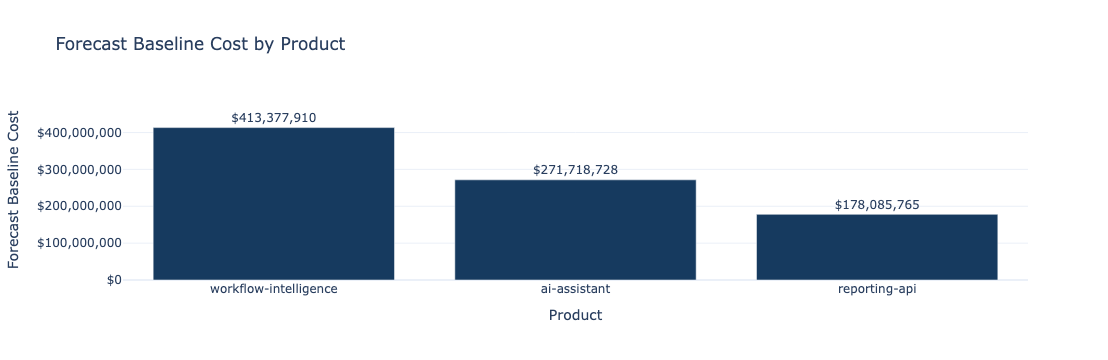

In [5]:
#plotly view of forecasted baseline cost, per product

forecast_by_product = (
    df.groupby("product_name", dropna=False)["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

fig = px.bar(
    forecast_by_product,
    x="product_name",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Forecast Baseline Cost by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Product",
    yaxis_title="Forecast Baseline Cost",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    showlegend=False
)

fig.show()

In [6]:
forecast_by_sla = (
    df.groupby("sla_tier")["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

forecast_by_sla


,sla_tier,forecast_baseline_cost
2,standard,3.756080e+08
1,premium,3.140796e+08
0,enterprise,1.734948e+08


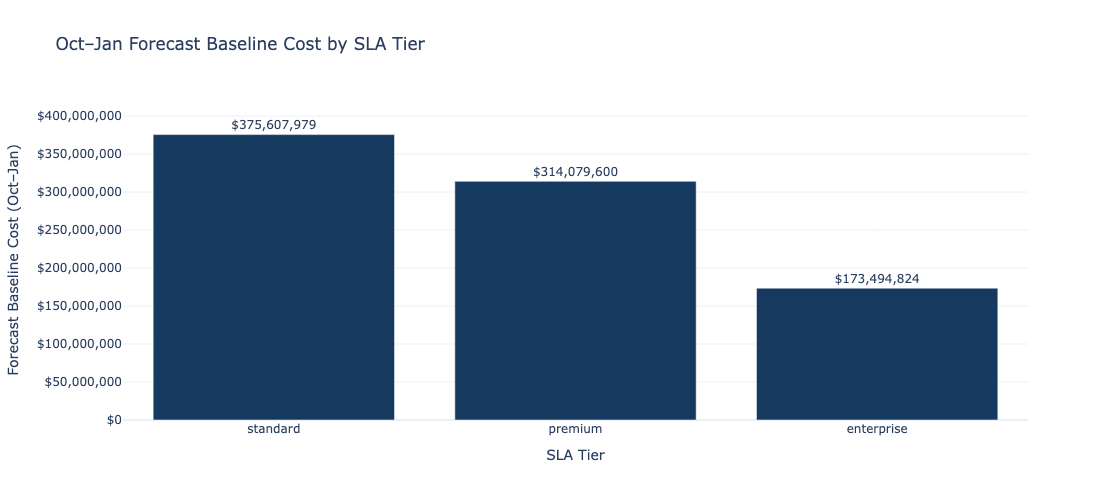

In [7]:
# view in dollars

fig = px.bar(
    forecast_by_sla,
    x="sla_tier",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Oct–Jan Forecast Baseline Cost by SLA Tier",
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{x}</b><br>Forecast Baseline Cost: $%{y:,.0f}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="SLA Tier",
    yaxis_title="Forecast Baseline Cost (Oct–Jan)",
    yaxis_tickformat="$,.0f",
    showlegend=False,
    height=500,
)

fig.show()

In [8]:
# check for what all columns are

df.columns.tolist()

['usage_date',
 'billing_period',
 'account_id',
 'account_name',
 'business_unit',
 'environment',
 'region',
 'service_name',
 'product_name',
 'team',
 'cost_usd',
 'usage_quantity',
 'usage_unit',
 'monthly_revenue_proxy',
 'active_customers',
 'workflows_processed',
 'enterprise_customer_flag',
 'sla_tier',
 'budget_amount',
 'forecast_baseline_cost',
 'acquisition_phase',
 'tag_owner',
 'tag_environment',
 'tag_product',
 'tag_cost_center',
 'allocation_status',
 'anomaly_flag']

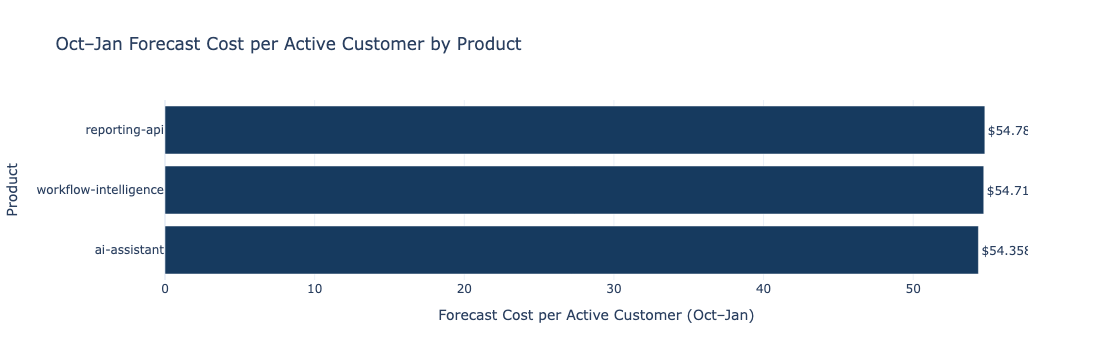

In [9]:
# checking cloud efficiency per customer

unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cost per Active Customer by Product",
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{y}</b><br>Cost per customer: $%{x:,.4f}<extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Active Customer (Oct–Jan)",
    yaxis_title="Product",
    showlegend=False,
)

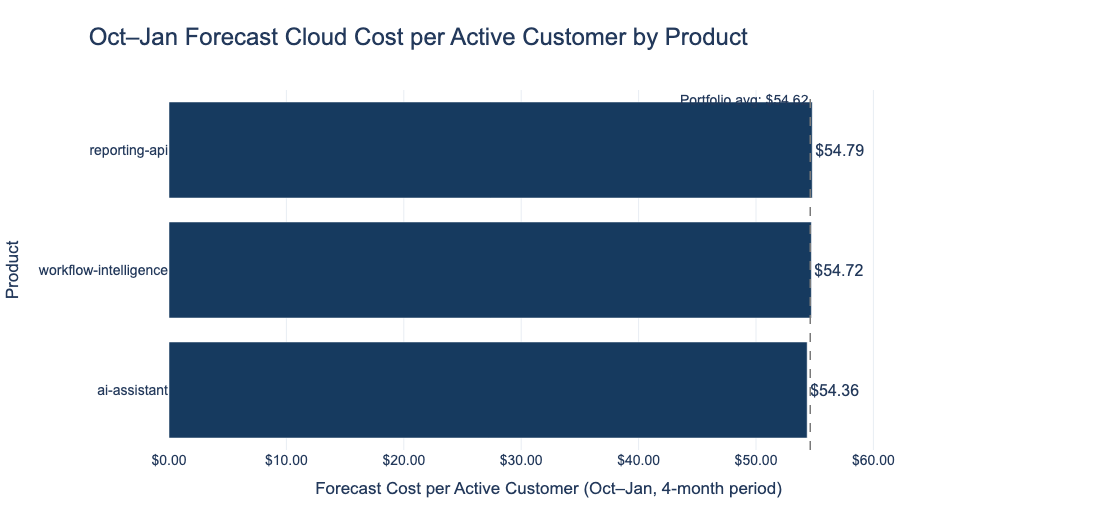

In [10]:
# better version

import numpy as np
import pandas as pd
import plotly.express as px

# Aggregate to product level
unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

# Guard against divide-by-zero
unit_df = unit_df[unit_df["active_customers"] > 0].copy()

# Unit metric
unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

# Sort for cleaner reading
unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

# Portfolio average
portfolio_avg = unit_df["cost_per_customer"].mean()

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cloud Cost per Active Customer by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.2f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per active customer: $%{x:,.2f}"
        "<extra></extra>"
    ),
)

fig.add_vline(
    x=portfolio_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${portfolio_avg:,.2f}",
    annotation_position="top left"
)

max_x = unit_df["cost_per_customer"].max()

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(
        x=0.08,
        xanchor="left",
        font=dict(size=24, color="#23395B")
    ),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Active Customer (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.2f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(
        title="Product",
        showgrid=False
    ),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(
        family="Arial",
        size=14,
        color="#23395B"
    )
)

fig.show()

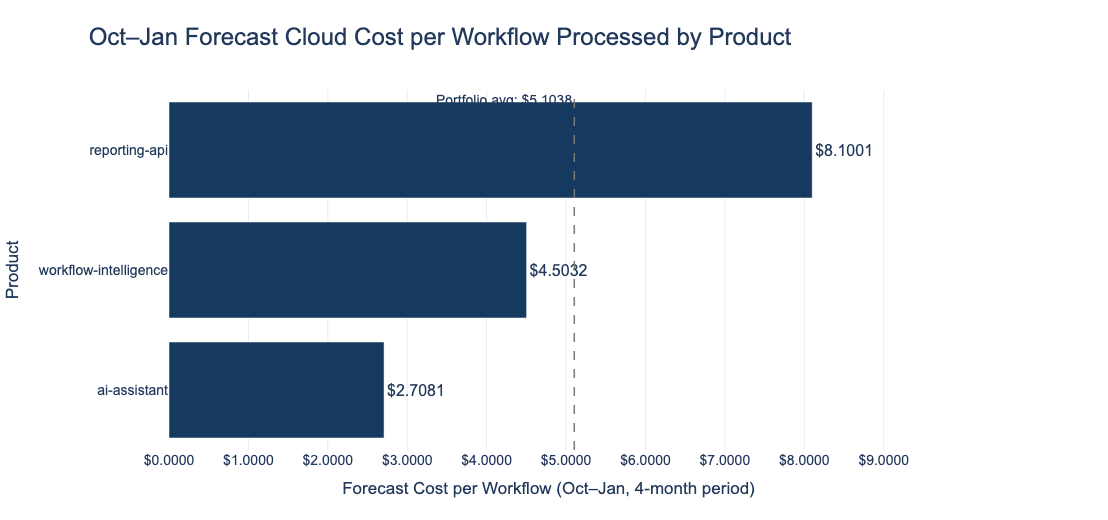

In [11]:
# checking cost per workflow processed

workflow_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

workflow_df = workflow_df[workflow_df["workflows_processed"] > 0].copy()

workflow_df["cost_per_workflow"] = (
    workflow_df["forecast_baseline_cost"] / workflow_df["workflows_processed"]
)

workflow_df = workflow_df.sort_values("cost_per_workflow", ascending=True)

workflow_avg = workflow_df["cost_per_workflow"].mean()

fig = px.bar(
    workflow_df,
    x="cost_per_workflow",
    y="product_name",
    orientation="h",
    text="cost_per_workflow",
    title="Oct–Jan Forecast Cloud Cost per Workflow Processed by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per workflow: $%{x:,.4f}"
        "<extra></extra>"
    ),
)

max_x = workflow_df["cost_per_workflow"].max()

fig.add_vline(
    x=workflow_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${workflow_avg:,.4f}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(x=0.08, xanchor="left", font=dict(size=24, color="#23395B")),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Workflow (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.4f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(title="Product", showgrid=False),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=14, color="#23395B")
)

fig.show()

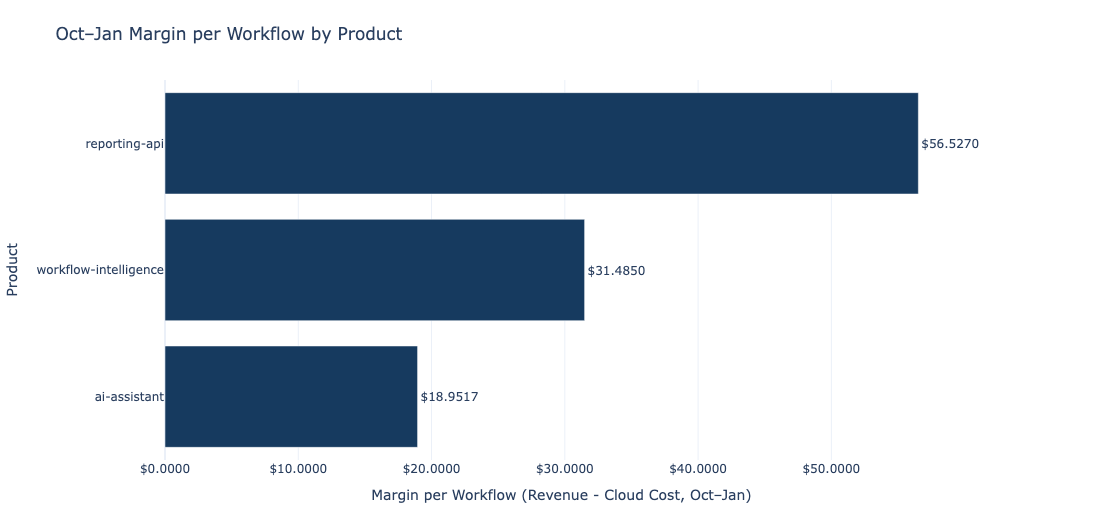

In [12]:
margin_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum"
      })
      .reset_index()
)

margin_df = margin_df[margin_df["workflows_processed"] > 0].copy()

margin_df["cost_per_workflow"] = (
    margin_df["forecast_baseline_cost"] / margin_df["workflows_processed"]
)

margin_df["revenue_per_workflow"] = (
    margin_df["monthly_revenue_proxy"] / margin_df["workflows_processed"]
)

margin_df["margin_per_workflow"] = (
    margin_df["revenue_per_workflow"] - margin_df["cost_per_workflow"]
)

margin_df = margin_df.sort_values("margin_per_workflow", ascending=True)

fig = px.bar(
    margin_df,
    x="margin_per_workflow",
    y="product_name",
    orientation="h",
    text="margin_per_workflow",
    title="Oct–Jan Margin per Workflow by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_title="Product",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=150, r=150, t=80, b=60)
)

fig.show()

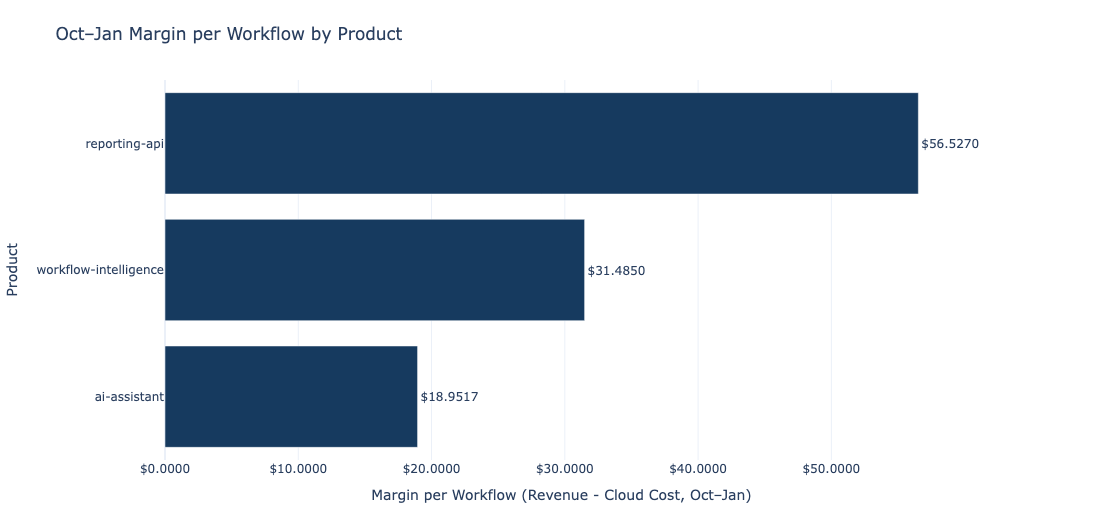

In [13]:
fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Margin per workflow: $%{x:,.4f}<extra></extra>"
)

fig.show()

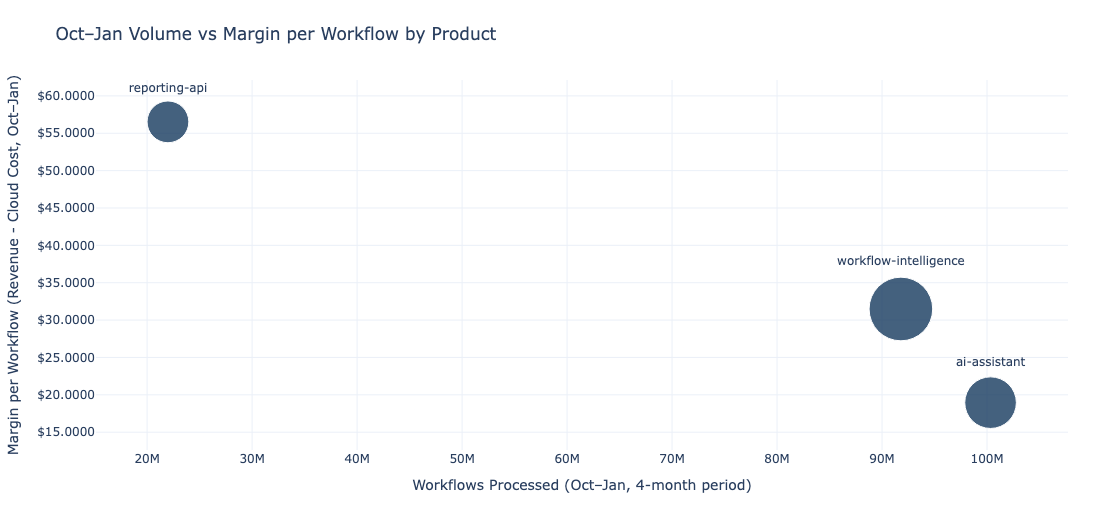

In [14]:

scatter_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

scatter_df = scatter_df[scatter_df["workflows_processed"] > 0].copy()

scatter_df["cost_per_workflow"] = (
    scatter_df["forecast_baseline_cost"] / scatter_df["workflows_processed"]
)

scatter_df["revenue_per_workflow"] = (
    scatter_df["monthly_revenue_proxy"] / scatter_df["workflows_processed"]
)

scatter_df["margin_per_workflow"] = (
    scatter_df["revenue_per_workflow"] - scatter_df["cost_per_workflow"]
)

fig = px.scatter(
    scatter_df,
    x="workflows_processed",
    y="margin_per_workflow",
    size="forecast_baseline_cost",
    size_max=45,
    text="product_name",
    title="Oct–Jan Volume vs Margin per Workflow by Product",
)

fig.update_traces(
    textposition="top center",
    marker=dict(color="#163A5F", opacity=0.8, line=dict(color="#ffffff", width=1)),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Workflows processed: %{x:,.0f}<br>"
        "Margin per workflow: $%{y:,.4f}<br>"
        "Forecast baseline cost: $%{marker.size:,.0f}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Workflows Processed (Oct–Jan, 4-month period)",
    yaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.4f",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=80, r=40, t=80, b=70),
)

fig.show()

In [15]:
# pursuing an "absolute economics view"

summary = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

summary["cost_per_workflow"] = summary["forecast_baseline_cost"] / summary["workflows_processed"]
summary["revenue_per_workflow"] = summary["monthly_revenue_proxy"] / summary["workflows_processed"]
summary["margin_per_workflow"] = summary["revenue_per_workflow"] - summary["cost_per_workflow"]

summary

,product_name,forecast_baseline_cost,monthly_revenue_proxy,workflows_processed,cost_per_workflow,revenue_per_workflow,margin_per_workflow
0,ai-assistant,2.717187e+08,2.173256e+09,100335822,2.708093,21.659824,18.951731
1,reporting-api,1.780858e+08,1.420863e+09,21985528,8.100136,64.627182,56.527046
2,workflow-intelligence,4.133779e+08,3.303570e+09,91795814,4.503233,35.988238,31.485005


In [16]:
# what if we double reporting-api workflows while keeping same efficiency

rep = summary[summary["product_name"] == "reporting-api"].iloc[0]

current_margin_total = rep["margin_per_workflow"] * rep["workflows_processed"]
double_volume_margin_total = rep["margin_per_workflow"] * (rep["workflows_processed"] * 2)

current_margin_total, double_volume_margin_total

(np.float64(1242776956.78), np.float64(2485553913.56))

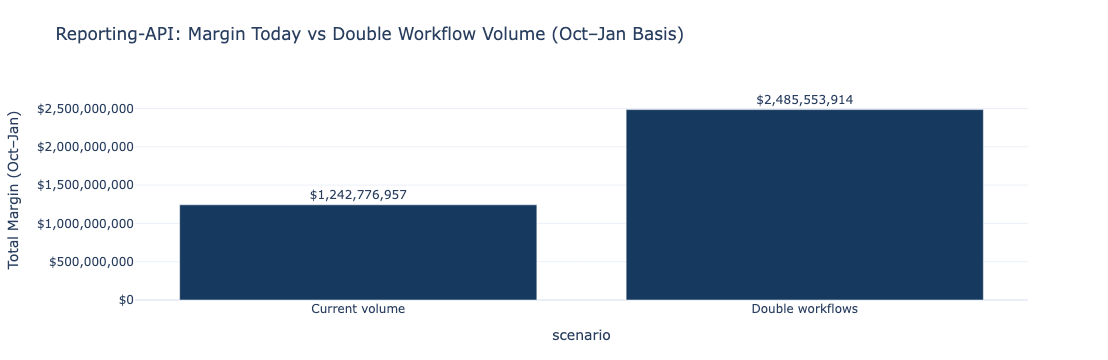

In [17]:
# visualizing the doubling 

rep = summary[summary["product_name"] == "reporting-api"].iloc[0]

current_margin_total = rep["margin_per_workflow"] * rep["workflows_processed"]
double_volume_margin_total = rep["margin_per_workflow"] * (rep["workflows_processed"] * 2)

scenario_df = pd.DataFrame({
    "scenario": ["Current volume", "Double workflows"],
    "total_margin": [current_margin_total, double_volume_margin_total],
})

fig = px.bar(
    scenario_df,
    x="scenario",
    y="total_margin",
    text="total_margin",
    title="Reporting-API: Margin Today vs Double Workflow Volume (Oct–Jan Basis)"
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
)

fig.update_layout(
    template="plotly_white",
    yaxis_title="Total Margin (Oct–Jan)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    showlegend=False,
    margin=dict(l=80, r=80, t=80, b=60),
)

fig.show()

In [18]:
# checking the relationship between enterprise product and reporting-api

ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

ent

,product_name,enterprise_customer_flag,workflows_processed,forecast_baseline_cost,monthly_revenue_proxy
0,ai-assistant,0,68972574,1.879987e+08,1.505019e+09
1,ai-assistant,1,31363248,8.372007e+07,6.682370e+08
2,reporting-api,0,15264489,1.223379e+08,9.801755e+08
3,reporting-api,1,6721039,5.574788e+07,4.406872e+08
4,workflow-intelligence,0,63828316,2.832110e+08,2.273909e+09
5,workflow-intelligence,1,27967498,1.301669e+08,1.029661e+09


In [19]:
# unit economics for enterprise vs non-enterprise

ent = ent[ent["workflows_processed"] > 0].copy()

ent["cost_per_workflow"] = (
    ent["forecast_baseline_cost"] / ent["workflows_processed"]
)
ent["revenue_per_workflow"] = (
    ent["monthly_revenue_proxy"] / ent["workflows_processed"]
)
ent["margin_per_workflow"] = (
    ent["revenue_per_workflow"] - ent["cost_per_workflow"]
)

In [20]:
ent_reporting = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["enterprise_customer_flag"] == True)
]
ent_reporting

,product_name,enterprise_customer_flag,workflows_processed,forecast_baseline_cost,monthly_revenue_proxy,cost_per_workflow,revenue_per_workflow,margin_per_workflow
3,reporting-api,1,6721039,55747880.32,4.406872e+08,8.294533,65.568319,57.273786


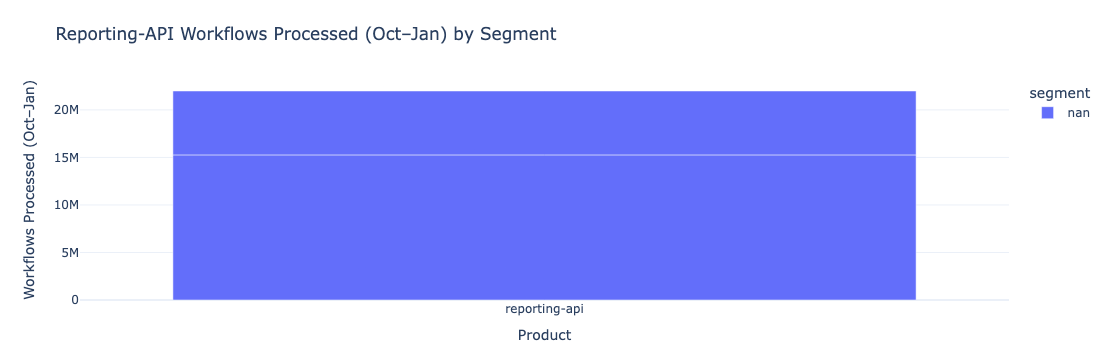

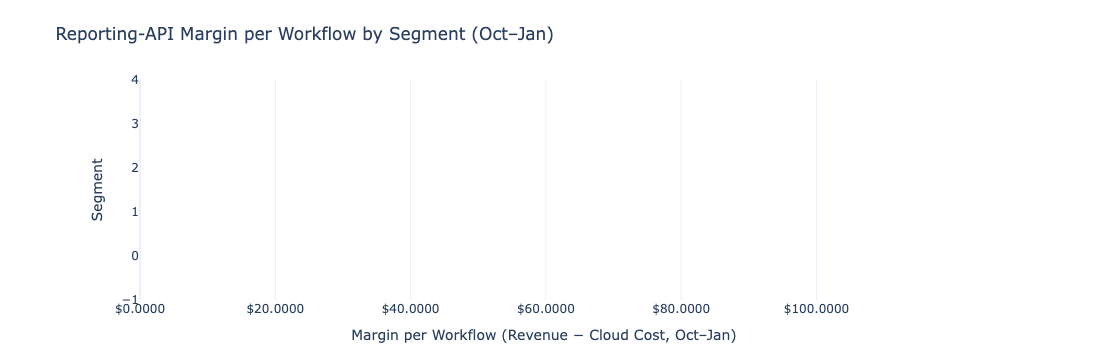

In [21]:
#visualizing enterprise vs non-enterprise

import pandas as pd
import plotly.express as px

# 1) Aggregate by product + enterprise flag
ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

# 2) Keep only reporting-api and non-zero workflows
ent_rep = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["workflows_processed"] > 0)
].copy()

# 3) Compute unit economics
ent_rep["segment"] = ent_rep["enterprise_customer_flag"].map(
    {True: "Enterprise", False: "Non-enterprise", 1: "Enterprise", 0: "Non-enterprise"}
)

ent_rep["cost_per_workflow"] = (
    ent_rep["forecast_baseline_cost"] / ent_rep["workflows_processed"]
)
ent_rep["revenue_per_workflow"] = (
    ent_rep["monthly_revenue_proxy"] / ent_rep["workflows_processed"]
)
ent_rep["margin_per_workflow"] = (
    ent_rep["revenue_per_workflow"] - ent_rep["cost_per_workflow"]
)

# --- Chart A: workflows by segment (stacked bar) ---

fig_vol = px.bar(
    ent_rep,
    x=["reporting-api", "reporting-api"],
    y="workflows_processed",
    color="segment",
    title="Reporting-API Workflows Processed (Oct–Jan) by Segment",
    labels={"x": "Product", "workflows_processed": "Workflows Processed (Oct–Jan)"},
)

fig_vol.update_traces(
    hovertemplate="<b>%{customdata}</b><br>Workflows: %{y:,.0f}<extra></extra>",
    customdata=ent_rep["segment"],
)

fig_vol.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis_title="Product",
    yaxis_title="Workflows Processed (Oct–Jan)",
    margin=dict(l=80, r=40, t=80, b=60),
)

fig_vol.show()

# --- Chart B: margin per workflow by segment ---

fig_margin = px.bar(
    ent_rep.sort_values("margin_per_workflow", ascending=True),
    x="margin_per_workflow",
    y="segment",
    orientation="h",
    text="margin_per_workflow",
    title="Reporting-API Margin per Workflow by Segment (Oct–Jan)",
)

fig_margin.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Margin per workflow: $%{x:,.4f}<br>"
        "Revenue per workflow: $%{customdata[0]:,.4f}<br>"
        "Cost per workflow:    $%{customdata[1]:,.4f}"
        "<extra></extra>"
    ),
    customdata=ent_rep[["revenue_per_workflow", "cost_per_workflow"]].to_numpy(),
)

fig_margin.update_layout(
    template="plotly_white",
    xaxis_title="Margin per Workflow (Revenue − Cloud Cost, Oct–Jan)",
    yaxis_title="Segment",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=140, r=160, t=80, b=60),
)

fig_margin.show()

In [22]:
df["enterprise_customer_flag"].value_counts(dropna=False)

enterprise_customer_flag
0    3458
1    1542
Name: count, dtype: int64

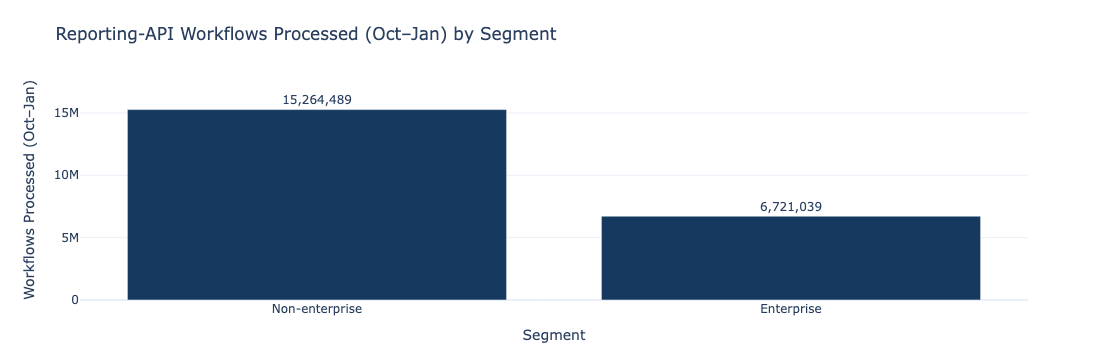

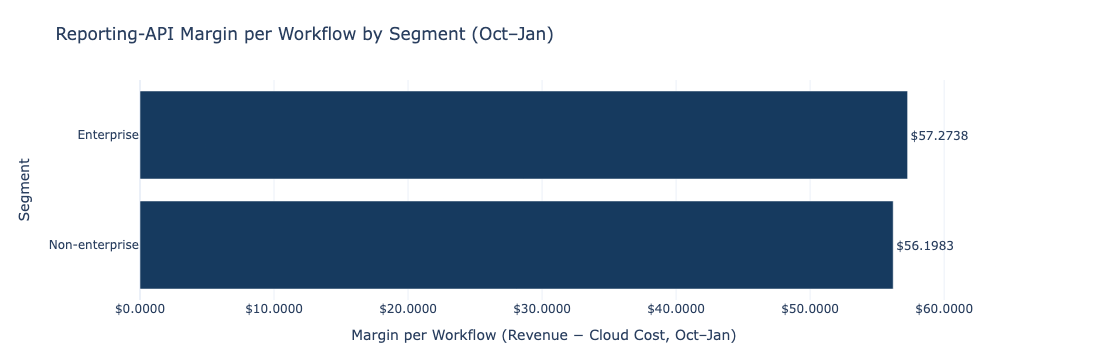

In [23]:
import numpy as np
import pandas as pd
import plotly.express as px

# Aggregate by product + enterprise flag
ent = (
    df.groupby(["product_name", "enterprise_customer_flag"], dropna=False)
      .agg({
          "workflows_processed": "sum",
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
      })
      .reset_index()
)

# Keep reporting-api only and non-zero workflows
ent_rep = ent[
    (ent["product_name"] == "reporting-api") &
    (ent["workflows_processed"] > 0)
].copy()

# Normalize the flag -> segment label
def to_segment(v):
    if pd.isna(v):
        return "Unknown"
    if v in [True, 1, "Y", "y", "Yes", "yes", "TRUE"]:
        return "Enterprise"
    if v in [False, 0, "N", "n", "No", "no", "FALSE"]:
        return "Non-enterprise"
    return str(v)

ent_rep["segment"] = ent_rep["enterprise_customer_flag"].apply(to_segment)

# If you only want Enterprise vs Non-enterprise, drop or group "Unknown" explicitly
ent_rep = ent_rep[ent_rep["segment"].isin(["Enterprise", "Non-enterprise"])].copy()

# Compute unit economics
ent_rep["cost_per_workflow"] = (
    ent_rep["forecast_baseline_cost"] / ent_rep["workflows_processed"]
)
ent_rep["revenue_per_workflow"] = (
    ent_rep["monthly_revenue_proxy"] / ent_rep["workflows_processed"]
)
ent_rep["margin_per_workflow"] = (
    ent_rep["revenue_per_workflow"] - ent_rep["cost_per_workflow"]
)

# --- Chart A: workflows by segment (simple bar) ---
fig_vol = px.bar(
    ent_rep,
    x="segment",
    y="workflows_processed",
    text="workflows_processed",
    title="Reporting-API Workflows Processed (Oct–Jan) by Segment",
)

fig_vol.update_traces(
    marker_color="#163A5F",
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{x}</b><br>Workflows: %{y:,.0f}<extra></extra>",
)

fig_vol.update_layout(
    template="plotly_white",
    xaxis_title="Segment",
    yaxis_title="Workflows Processed (Oct–Jan)",
    showlegend=False,
    margin=dict(l=80, r=80, t=80, b=60),
)

fig_vol.show()

# --- Chart B: margin per workflow by segment ---
fig_margin = px.bar(
    ent_rep.sort_values("margin_per_workflow", ascending=True),
    x="margin_per_workflow",
    y="segment",
    orientation="h",
    text="margin_per_workflow",
    title="Reporting-API Margin per Workflow by Segment (Oct–Jan)",
)

fig_margin.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Margin per workflow: $%{x:,.4f}<br>"
        "Revenue per workflow: $%{customdata[0]:,.4f}<br>"
        "Cost per workflow:    $%{customdata[1]:,.4f}"
        "<extra></extra>"
    ),
    customdata=ent_rep[["revenue_per_workflow", "cost_per_workflow"]].to_numpy(),
)

fig_margin.update_layout(
    template="plotly_white",
    xaxis_title="Margin per Workflow (Revenue − Cloud Cost, Oct–Jan)",
    yaxis_title="Segment",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=140, r=160, t=80, b=60),
)

fig_margin.show()

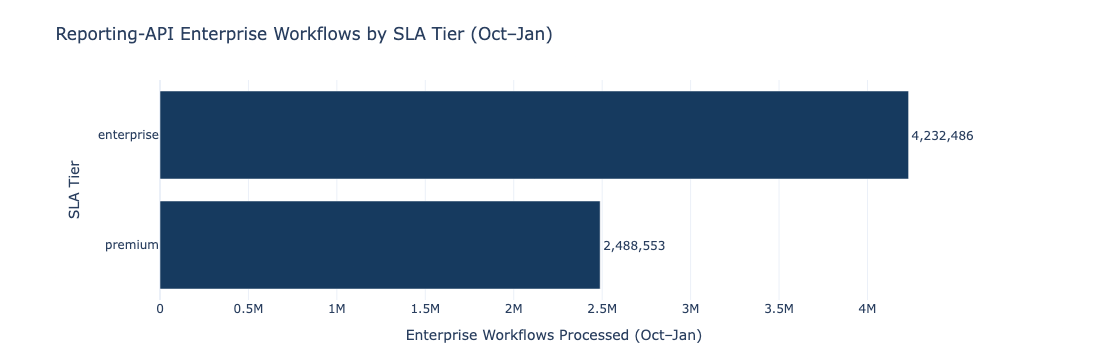

In [24]:
# Filter to reporting-api, enterprise only
rep_ent_sla = (
    df[
        (df["product_name"] == "reporting-api") &
        (df["enterprise_customer_flag"] == True)
    ]
    .groupby("sla_tier", dropna=False)
    .agg({
        "workflows_processed": "sum",
        "forecast_baseline_cost": "sum",
        "monthly_revenue_proxy": "sum",
    })
    .reset_index()
)

rep_ent_sla = rep_ent_sla[rep_ent_sla["workflows_processed"] > 0].copy()

# Unit economics by SLA tier
rep_ent_sla["cost_per_workflow"] = (
    rep_ent_sla["forecast_baseline_cost"] / rep_ent_sla["workflows_processed"]
)
rep_ent_sla["revenue_per_workflow"] = (
    rep_ent_sla["monthly_revenue_proxy"] / rep_ent_sla["workflows_processed"]
)
rep_ent_sla["margin_per_workflow"] = (
    rep_ent_sla["revenue_per_workflow"] - rep_ent_sla["cost_per_workflow"]
)

# Sort by workflows to see dominant SLA tier at a glance
rep_ent_sla = rep_ent_sla.sort_values("workflows_processed", ascending=True)

fig_sla = px.bar(
    rep_ent_sla,
    x="workflows_processed",
    y="sla_tier",
    orientation="h",
    text="workflows_processed",
    title="Reporting-API Enterprise Workflows by SLA Tier (Oct–Jan)",
)

fig_sla.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    cliponaxis=False,
    marker_color="#163A5F",
    hovertemplate=(
        "<b>SLA tier: %{y}</b><br>"
        "Workflows: %{x:,.0f}<br>"
        "Cost per workflow: $%{customdata[0]:,.4f}<br>"
        "Revenue per workflow: $%{customdata[1]:,.4f}<br>"
        "Margin per workflow: $%{customdata[2]:,.4f}"
        "<extra></extra>"
    ),
    customdata=rep_ent_sla[
        ["cost_per_workflow", "revenue_per_workflow", "margin_per_workflow"]
    ].to_numpy(),
)

fig_sla.update_layout(
    template="plotly_white",
    xaxis_title="Enterprise Workflows Processed (Oct–Jan)",
    yaxis_title="SLA Tier",
    showlegend=False,
    margin=dict(l=160, r=160, t=80, b=60),
)

fig_sla.show()

In [25]:
# checking time series for cost first


df["usage_date"] = pd.to_datetime(df["usage_date"])
df["month"] = df["usage_date"].dt.to_period("M").dt.to_timestamp()

In [26]:
# cost per workflow over time

monthly = (
    df.groupby("month", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

monthly = monthly[monthly["workflows_processed"] > 0].copy()

monthly["cost_per_workflow"] = (
    monthly["forecast_baseline_cost"] / monthly["workflows_processed"]
)

monthly

,month,forecast_baseline_cost,workflows_processed,cost_per_workflow
0,2025-10-01,2.152951e+08,54215840,3.971074
1,2025-11-01,2.080368e+08,49184500,4.229722
2,2025-12-01,2.197793e+08,51471168,4.269949
3,2026-01-01,2.200713e+08,59245656,3.714556


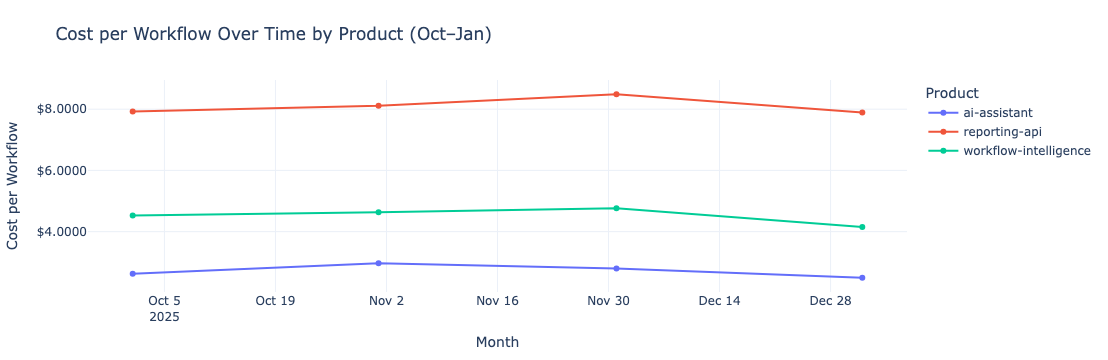

In [27]:
# is unit efficiency changing per product

monthly_prod = (
    df.groupby(["month", "product_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

monthly_prod = monthly_prod[monthly_prod["workflows_processed"] > 0].copy()

monthly_prod["cost_per_workflow"] = (
    monthly_prod["forecast_baseline_cost"] / monthly_prod["workflows_processed"]
)

fig = px.line(
    monthly_prod,
    x="month",
    y="cost_per_workflow",
    color="product_name",
    markers=True,
    title="Cost per Workflow Over Time by Product (Oct–Jan)",
)

fig.update_traces(
    hovertemplate=(
        "<b>%{x|%Y-%m}</b><br>"
        "%{legendgroup}: $%{y:,.4f} per workflow"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Cost per Workflow",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.4f",
    margin=dict(l=80, r=200, t=80, b=60),
    legend_title="Product",
)

fig.show()

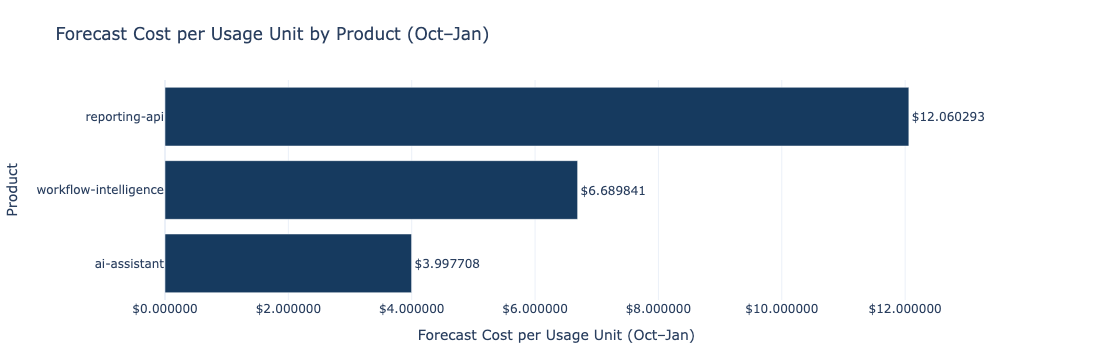

In [28]:
# checking cost per usage unit

import pandas as pd
import plotly.express as px

usage_prod = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

usage_prod = usage_prod[usage_prod["usage_quantity"] > 0].copy()
usage_prod["cost_per_usage_unit"] = (
    usage_prod["forecast_baseline_cost"] / usage_prod["usage_quantity"]
)

fig = px.bar(
    usage_prod.sort_values("cost_per_usage_unit", ascending=True),
    x="cost_per_usage_unit",
    y="product_name",
    orientation="h",
    text="cost_per_usage_unit",
    title="Forecast Cost per Usage Unit by Product (Oct–Jan)",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.6f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Cost per usage unit: $%{x:,.6f}<extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Usage Unit (Oct–Jan)",
    yaxis_title="Product",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.6f",
    showlegend=False,
    margin=dict(l=150, r=160, t=80, b=60),
)

fig.show()

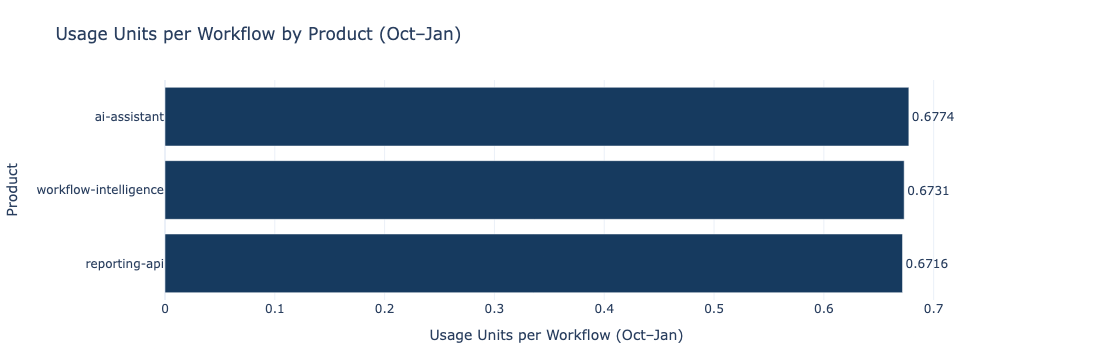

In [29]:
# checking usage units per workflow

usage_intensity = (
    df.groupby("product_name", dropna=False)
      .agg({
          "usage_quantity": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

usage_intensity = usage_intensity[usage_intensity["workflows_processed"] > 0].copy()

usage_intensity["usage_per_workflow"] = (
    usage_intensity["usage_quantity"] / usage_intensity["workflows_processed"]
)

fig = px.bar(
    usage_intensity.sort_values("usage_per_workflow", ascending=True),
    x="usage_per_workflow",
    y="product_name",
    orientation="h",
    text="usage_per_workflow",
    title="Usage Units per Workflow by Product (Oct–Jan)",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Usage per workflow: %{x:,.4f} %{customdata}<extra></extra>",
    customdata=df["usage_unit"].mode()  # simple placeholder if unit is consistent
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Usage Units per Workflow (Oct–Jan)",
    yaxis_title="Product",
    showlegend=False,
    margin=dict(l=150, r=160, t=80, b=60),
)

fig.show()

In [30]:
# service usage for reproting api

svc_usage = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

svc_usage = svc_usage[svc_usage["usage_quantity"] > 0].copy()
svc_usage["cost_per_usage_unit"] = (
    svc_usage["forecast_baseline_cost"] / svc_usage["usage_quantity"]
)

svc_usage[svc_usage["product_name"] == "reporting-api"].sort_values(
    "cost_per_usage_unit", ascending=False
).head(10)

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362
21,reporting-api,Data Transfer,16975687.15,1371404.54,12.378322
22,reporting-api,NAT Gateway,14471126.93,1174574.17,12.320318
16,reporting-api,Amazon CloudWatch,15506842.73,1451879.30,10.680532
14,reporting-api,AWS Lambda,15829743.55,1716627.12,9.221422
19,reporting-api,Amazon RDS,15287133.55,1695381.66,9.016928
17,reporting-api,Amazon EBS,15173699.16,1818031.22,8.346226


In [31]:
#checking service usage for each prodcut now

svc_usage_all = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
)

svc_usage_all = svc_usage_all[svc_usage_all["usage_quantity"] > 0].copy()
svc_usage_all["cost_per_usage_unit"] = (
    svc_usage_all["forecast_baseline_cost"] / svc_usage_all["usage_quantity"]
)

svc_usage_all.sort_values("cost_per_usage_unit", ascending=False).head(20)

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
35,workflow-intelligence,Support / Shared Platform,34418752.45,955003.78,36.040436
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
11,ai-assistant,Support / Shared Platform,25294318.61,1105226.78,22.886089
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362


In [32]:
# getting to a visual for key services

key_services = [
    "Support / Shared Platform",
    "Amazon Athena",
    "AWS Glue",
    "Amazon S3",
    "Data Transfer",
    "NAT Gateway",
]

svc_selected = svc_usage_all[svc_usage_all["service_name"].isin(key_services)].copy()

# Only keep reasonably sized services if you want
svc_selected = svc_selected.sort_values(
    ["service_name", "product_name"]
)

svc_selected

,product_name,service_name,forecast_baseline_cost,usage_quantity,cost_per_usage_unit
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
8,ai-assistant,Amazon S3,23441100.57,5619912.87,4.171079
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362
32,workflow-intelligence,Amazon S3,32557624.89,4311007.99,7.552207
9,ai-assistant,Data Transfer,22234447.40,5296556.80,4.197906


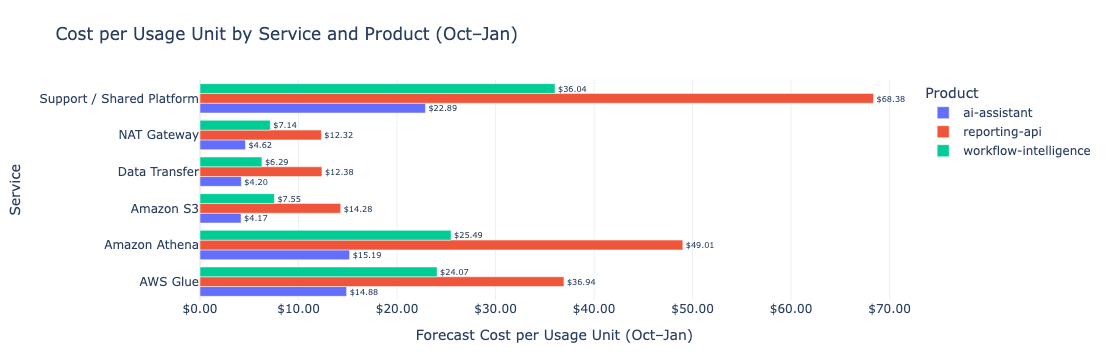

In [33]:
# visualizing


fig = px.bar(
    svc_selected,
    x="cost_per_usage_unit",
    y="service_name",
    color="product_name",
    barmode="group",
    orientation="h",
    text="cost_per_usage_unit",
    title="Cost per Usage Unit by Service and Product (Oct–Jan)",
)

fig.update_traces(
    texttemplate="$%{text:,.2f}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Product: %{legendgroup}<br>"
        "Cost per usage unit: $%{x:,.4f}<br>"
        "<extra></extra>"
    ),
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Usage Unit (Oct–Jan)",
    yaxis_title="Service",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.2f",
    margin=dict(l=200, r=160, t=80, b=60),
    legend_title="Product",
)

fig.show()

In [34]:
# now to create a single, simple method for baseline analysis

import pandas as pd

# 0) Ensure dates and a month key
df["usage_date"] = pd.to_datetime(df["usage_date"])
df["billing_period"] = pd.to_datetime(df["billing_period"])
df["month"] = df["usage_date"].dt.to_period("M").dt.to_timestamp()

# 1) Baseline by month (forecast vs actual)
baseline_monthly = (
    df.groupby("month", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

baseline_monthly["forecast_vs_actual_delta"] = (
    baseline_monthly["forecast_cost_usd"] - baseline_monthly["actual_cost_usd"]
)

# 2) By product: totals + unit economics
by_product = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
          "active_customers": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# Guard against zeros
by_product = by_product[
    (by_product["workflows_processed"] > 0) &
    (by_product["active_customers"] > 0) &
    (by_product["usage_quantity"] > 0)
].copy()

by_product["cost_per_workflow"] = (
    by_product["forecast_cost_usd"] / by_product["workflows_processed"]
)
by_product["revenue_per_workflow"] = (
    by_product["monthly_revenue_proxy"] / by_product["workflows_processed"]
)
by_product["margin_per_workflow"] = (
    by_product["revenue_per_workflow"] - by_product["cost_per_workflow"]
)

by_product["cost_per_customer"] = (
    by_product["forecast_cost_usd"] / by_product["active_customers"]
)
by_product["cost_per_usage_unit"] = (
    by_product["forecast_cost_usd"] / by_product["usage_quantity"]
)
by_product["usage_units_per_workflow"] = (
    by_product["usage_quantity"] / by_product["workflows_processed"]
)

# 3) Spend by environment + product
# Prefer tag_environment if it is more complete; fallback to environment
env_col = "tag_environment" if df["tag_environment"].notna().any() else "environment"

by_env_product = (
    df.groupby([env_col, "product_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          env_col: "environment",
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# 4) Spend by account (maps to acquired-ai-platform, legacy-core-prod, shared-services)
by_account = (
    df.groupby(["account_id", "account_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "cost_usd": "sum",
      })
      .reset_index()
      .rename(columns={
          "forecast_baseline_cost": "forecast_cost_usd",
          "cost_usd": "actual_cost_usd",
      })
)

# 5) Service usage by product (for per-unit cost analysis)
service_usage = (
    df.groupby(["product_name", "service_name"], dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "usage_quantity": "sum",
      })
      .reset_index()
      .rename(columns={"forecast_baseline_cost": "forecast_cost_usd"})
)

service_usage = service_usage[service_usage["usage_quantity"] > 0].copy()
service_usage["cost_per_usage_unit"] = (
    service_usage["forecast_cost_usd"] / service_usage["usage_quantity"]
)

# Optional: quick views
display(baseline_monthly)
display(by_product.sort_values("forecast_cost_usd", ascending=False))
display(by_env_product.sort_values("forecast_cost_usd", ascending=False).head(20))
display(by_account.sort_values("forecast_cost_usd", ascending=False))
display(service_usage.sort_values("cost_per_usage_unit", ascending=False).head(20))

,month,forecast_cost_usd,actual_cost_usd,forecast_vs_actual_delta
0,2025-10-01,2.152951e+08,22003.75,2.152731e+08
1,2025-11-01,2.080368e+08,24096.05,2.080127e+08
2,2025-12-01,2.197793e+08,28912.71,2.197504e+08
3,2026-01-01,2.200713e+08,35007.89,2.200363e+08


,product_name,forecast_cost_usd,actual_cost_usd,monthly_revenue_proxy,workflows_processed,active_customers,usage_quantity,cost_per_workflow,revenue_per_workflow,margin_per_workflow,cost_per_customer,cost_per_usage_unit,usage_units_per_workflow
2,workflow-intelligence,4.133779e+08,47452.29,3.303570e+09,91795814,7554934,61791885.94,4.503233,35.988238,31.485005,54.716283,6.689841,0.673145
0,ai-assistant,2.717187e+08,51472.71,2.173256e+09,100335822,4998670,67968635.76,2.708093,21.659824,18.951731,54.358205,3.997708,0.677411
1,reporting-api,1.780858e+08,11095.40,1.420863e+09,21985528,3250402,14766288.86,8.100136,64.627182,56.527046,54.788843,12.060293,0.671637


,environment,product_name,forecast_cost_usd,actual_cost_usd
5,prod,workflow-intelligence,1.534564e+08,27800.27
14,staging,workflow-intelligence,1.188062e+08,10452.23
2,dev,workflow-intelligence,1.166323e+08,5653.56
3,prod,ai-assistant,9.646834e+07,30456.66
12,staging,ai-assistant,8.267510e+07,12579.58
0,dev,ai-assistant,7.549600e+07,5859.98
4,prod,reporting-api,6.339194e+07,6767.21
13,staging,reporting-api,5.778789e+07,2508.31
1,dev,reporting-api,4.527625e+07,1150.51
11,stage,workflow-intelligence,1.054045e+07,1655.58


,account_id,account_name,forecast_cost_usd,actual_cost_usd
0,1001,legacy-core-prod,2.955491e+08,35971.40
1,1002,acquired-ai-platform,2.883953e+08,39302.82
2,1003,shared-services,2.792380e+08,34746.18


,product_name,service_name,forecast_cost_usd,usage_quantity,cost_per_usage_unit
23,reporting-api,Support / Shared Platform,12785600.58,186991.24,68.375399
15,reporting-api,Amazon Athena,15115308.46,308404.29,49.011343
13,reporting-api,AWS Glue,15001876.43,406062.83,36.944717
35,workflow-intelligence,Support / Shared Platform,34418752.45,955003.78,36.040436
27,workflow-intelligence,Amazon Athena,36578268.80,1435076.16,25.488730
25,workflow-intelligence,AWS Glue,31789457.37,1320807.51,24.068199
11,ai-assistant,Support / Shared Platform,25294318.61,1105226.78,22.886089
3,ai-assistant,Amazon Athena,19418893.73,1278343.39,15.190671
1,ai-assistant,AWS Glue,22083310.50,1483717.86,14.883767
20,reporting-api,Amazon S3,13671432.79,957090.91,14.284362


In [35]:
# unit economics summary

unit_summary = by_product[[
    "product_name",
    "forecast_cost_usd",
    "monthly_revenue_proxy",
    "workflows_processed",
    "active_customers",
    "cost_per_workflow",
    "revenue_per_workflow",
    "margin_per_workflow",
    "cost_per_customer",
    "cost_per_usage_unit",
    "usage_units_per_workflow",
]].sort_values("margin_per_workflow", ascending=False)

unit_summary

,product_name,forecast_cost_usd,monthly_revenue_proxy,workflows_processed,active_customers,cost_per_workflow,revenue_per_workflow,margin_per_workflow,cost_per_customer,cost_per_usage_unit,usage_units_per_workflow
1,reporting-api,1.780858e+08,1.420863e+09,21985528,3250402,8.100136,64.627182,56.527046,54.788843,12.060293,0.671637
2,workflow-intelligence,4.133779e+08,3.303570e+09,91795814,7554934,4.503233,35.988238,31.485005,54.716283,6.689841,0.673145
0,ai-assistant,2.717187e+08,2.173256e+09,100335822,4998670,2.708093,21.659824,18.951731,54.358205,3.997708,0.677411


In [36]:
from pyathena import connect
import pandas as pd

region = "us-east-1"
s3_staging_dir = "s3://clarionflow-ai-finops-data/athena-results/"
database = "clarionflow-ai-finops"

conn = connect(
    s3_staging_dir=s3_staging_dir,
    region_name=region,
    schema_name=database,
)

In [37]:
import boto3
from pyathena import connect
import pandas as pd

profile = "finops-dojo"
region = "us-east-1"          
s3_staging_dir = "s3://clarionflow-ai-finops-data/athena-results/"
database = "clarionflow-ai-finops"

session = boto3.Session(profile_name=profile, region_name=region)

conn = connect(
    s3_staging_dir=s3_staging_dir,
    region_name=region,
    schema_name=database,
    aws_access_key_id=session.get_credentials().access_key,
    aws_secret_access_key=session.get_credentials().secret_key,
    aws_session_token=session.get_credentials().token,
)

In [38]:
sql = """
SELECT environment,
       SUM(cost_usd) AS cost_usd
FROM billing_case01
GROUP BY environment
ORDER BY cost_usd DESC
"""

df_env = pd.read_sql(sql, conn)
df_env

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/4035935106.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_env = pd.read_sql(sql, conn)


,environment,cost_usd
0,product-analytics,39770361.58
1,ml-engineering,36209225.31
2,platform,34470546.52
3,data,34076677.15


In [39]:
sql = """
SELECT
    account_name,
    environment,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
GROUP BY account_name, environment
ORDER BY cost_usd DESC
"""

df_env = pd.read_sql(sql, conn)
df_env

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/917264876.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_env = pd.read_sql(sql, conn)


,account_name,environment,cost_usd
0,ai-products,product-analytics,13864800.85
1,core-platform,product-analytics,13510563.95
2,ai-products,ml-engineering,12441324.76
3,core-platform,ml-engineering,12399468.91
4,shared-ops,product-analytics,12394996.78
5,ai-products,data,12162691.90
6,core-platform,data,11803841.36
7,core-platform,platform,11661576.05
8,shared-ops,platform,11641784.32
9,shared-ops,ml-engineering,11368431.64


In [40]:
sql = """
SELECT
    account_name,
    environment AS env_tier,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE environment = 'product-analytics'
GROUP BY account_name, environment
ORDER BY cost_usd DESC
"""

df_prod_analytics = pd.read_sql(sql, conn)
df_prod_analytics

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/1902167596.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_prod_analytics = pd.read_sql(sql, conn)


,account_name,env_tier,cost_usd
0,ai-products,product-analytics,13864800.85
1,core-platform,product-analytics,13510563.95
2,shared-ops,product-analytics,12394996.78


In [41]:
sql = """
SELECT
    account_name,
    service_name,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE environment = 'product-analytics'
GROUP BY account_name, service_name
ORDER BY account_name, cost_usd DESC
"""

df_prod_analytics_services = pd.read_sql(sql, conn)
df_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/3879994487.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_prod_analytics_services = pd.read_sql(sql, conn)


,account_name,service_name,cost_usd
0,ai-products,prod,9490904.78
1,ai-products,staging,2744789.70
2,ai-products,dev,1629106.37
3,core-platform,prod,8712218.41
4,core-platform,staging,3432060.31
5,core-platform,dev,1366285.23
6,shared-ops,prod,7777565.67
7,shared-ops,staging,2914698.50
8,shared-ops,dev,1702732.61


In [42]:
sql = """
SELECT
    service_name,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE account_name = 'ai-products'
  AND environment = 'product-analytics'
  AND service_name IS NOT NULL
GROUP BY service_name
ORDER BY cost_usd DESC
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/4020124374.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,service_name,cost_usd
0,prod,9490904.78
1,staging,2744789.70
2,dev,1629106.37


In [43]:
sql = """
SELECT
  billing_period_start_date,
  account_name,
  service_name,
  environment,
  cost_usd
FROM billing_case01
LIMIT 20;
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/3410946696.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,billing_period_start_date,account_name,service_name,environment,cost_usd
0,2025-10-01,core-platform,staging,ml-engineering,51593.79
1,2025-10-01,core-platform,dev,product-analytics,17571.58
2,2025-10-01,core-platform,prod,data,101102.99
3,2025-10-01,core-platform,dev,product-analytics,20808.66
4,2025-10-01,core-platform,staging,ml-engineering,5428.21
5,2025-10-01,core-platform,prod,platform,113059.68
6,2025-10-01,core-platform,dev,platform,25939.90
7,2025-10-01,core-platform,prod,platform,67507.37
8,2025-10-01,core-platform,prod,platform,107725.23
9,2025-10-01,core-platform,prod,product-analytics,93599.46


In [44]:
sql = "SHOW COLUMNS IN billing_case01"
df_cols = pd.read_sql(sql, conn)
df_cols

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/2616186053.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cols = pd.read_sql(sql, conn)


,field
0,billing_period_start_date
1,billing_period_end_date
2,usage_date
3,account_id
4,account_name
5,service_name
6,usage_type
7,operation
8,region
9,environment


In [45]:
sql = """
SELECT
    operation,
    SUM(cost_usd) AS cost_usd
FROM billing_case01
WHERE account_name = 'ai-products'
  AND environment = 'product-analytics'
  AND operation IS NOT NULL
GROUP BY operation
ORDER BY cost_usd DESC
"""

df_ai_prod_analytics_services = pd.read_sql(sql, conn)
df_ai_prod_analytics_services

/var/folders/hv/w4t1jknx621dxcgdzhxq5l5w0000gn/T/ipykernel_94198/396595216.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ai_prod_analytics_services = pd.read_sql(sql, conn)


,operation,cost_usd
0,AWS Fargate,2528431.62
1,Amazon RDS,1847637.02
2,Amazon EBS,1818743.07
3,AWS Lambda,1666452.90
4,Amazon EC2,1351165.30
5,Amazon S3,1110907.14
6,NAT Gateway,1083476.39
7,Amazon CloudWatch,1061935.65
8,Data Transfer,634969.03
9,AWS Glue,300443.52
